In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv('Covid Data.csv')

# Preview data
df.head()


,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,DATE_DIED,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,...,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU
0,2,1,1,1,03/05/2020,97,1,65,2,2,...,2,2,1,2,2,2,2,2,3,97
1,2,1,2,1,03/06/2020,97,1,72,97,2,...,2,2,1,2,2,1,1,2,5,97
2,2,1,2,2,09/06/2020,1,2,55,97,1,...,2,2,2,2,2,2,2,2,3,2
3,2,1,1,1,12/06/2020,97,2,53,2,2,...,2,2,2,2,2,2,2,2,7,97
4,2,1,2,1,21/06/2020,97,2,68,97,1,...,2,2,1,2,2,2,2,2,3,97


In [2]:
# Convert date column
df['DATE_DIED'] = pd.to_datetime(df['DATE_DIED'], errors='coerce')

# Create death flag
df['DEATH'] = df['DATE_DIED'].notnull().astype(int)

# Map categorical codes
df['SEX'] = df['SEX'].map({1: 'Female', 2: 'Male'})
df['PATIENT_TYPE'] = df['PATIENT_TYPE'].map({1: 'Outpatient', 2: 'Hospitalized'})
df['ICU'] = df['ICU'].map({1: 'Yes', 2: 'No'})

# Confirm cleaning
df.head()


,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,DATE_DIED,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,...,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU,DEATH
0,2,1,Female,Outpatient,2020-03-05,97,1,65,2,2,...,2,1,2,2,2,2,2,3,NaN,1
1,2,1,Male,Outpatient,2020-03-06,97,1,72,97,2,...,2,1,2,2,1,1,2,5,NaN,1
2,2,1,Male,Hospitalized,2020-09-06,1,2,55,97,1,...,2,2,2,2,2,2,2,3,No,1
3,2,1,Female,Outpatient,2020-12-06,97,2,53,2,2,...,2,2,2,2,2,2,2,7,NaN,1
4,2,1,Male,Outpatient,NaT,97,2,68,97,1,...,2,1,2,2,2,2,2,3,NaN,0


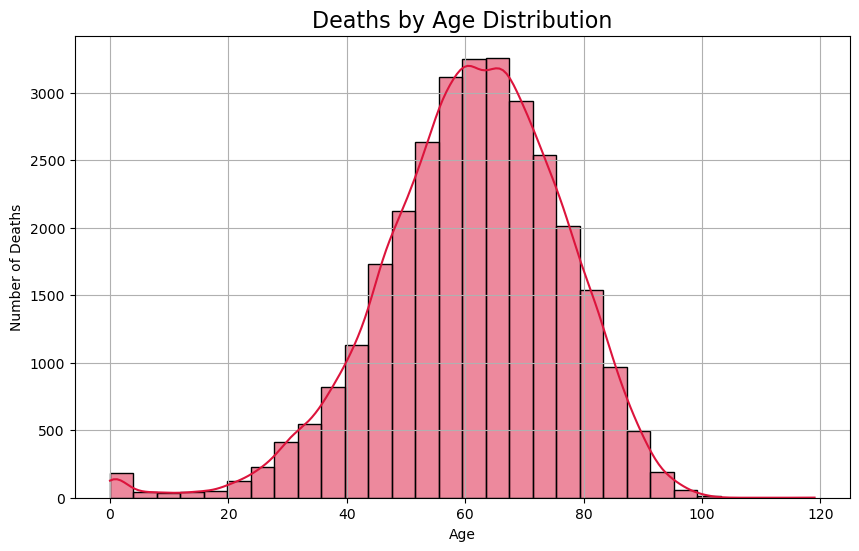

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.histplot(data=df[df['DEATH'] == 1], x='AGE', bins=30, kde=True, color='crimson')
plt.title('Deaths by Age Distribution', fontsize=16)
plt.xlabel('Age')
plt.ylabel('Number of Deaths')
plt.grid(True)
plt.show()


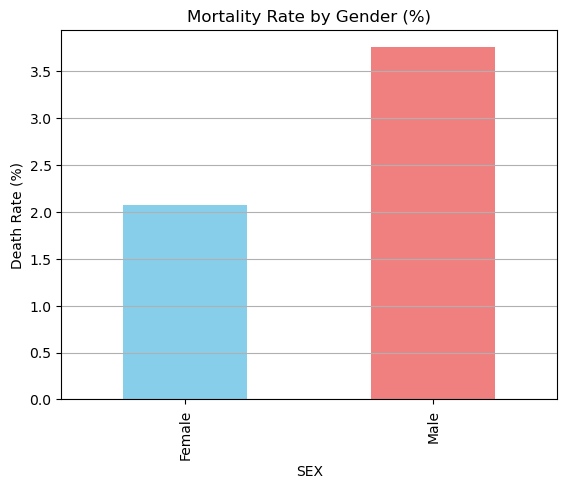

In [4]:
mortality_by_gender = df.groupby('SEX')['DEATH'].mean() * 100
mortality_by_gender.plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.title('Mortality Rate by Gender (%)')
plt.ylabel('Death Rate (%)')
plt.grid(axis='y')
plt.show()


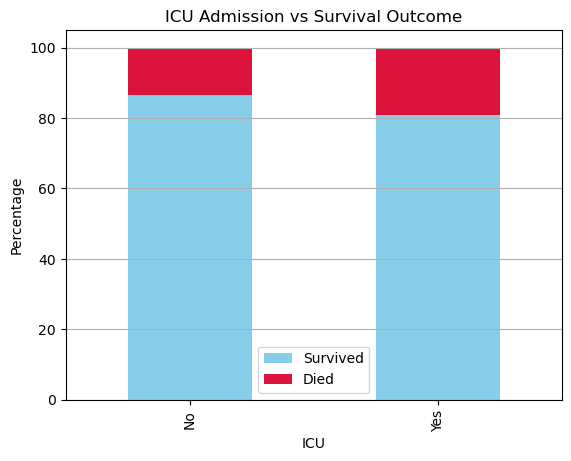

In [5]:
icu_death = pd.crosstab(df['ICU'], df['DEATH'], normalize='index') * 100
icu_death.plot(kind='bar', stacked=True, color=['skyblue', 'crimson'])
plt.title('ICU Admission vs Survival Outcome')
plt.ylabel('Percentage')
plt.legend(['Survived', 'Died'])
plt.grid(axis='y')
plt.show()


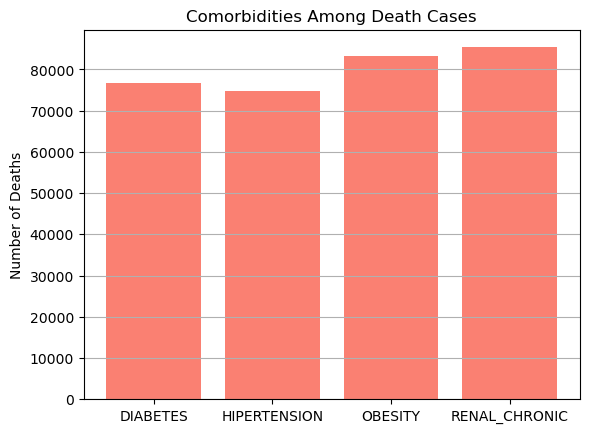

In [6]:
comorbidities = ['DIABETES', 'HIPERTENSION', 'OBESITY', 'RENAL_CHRONIC']

death_cases = df[df['DEATH'] == 1]
comorbidity_counts = {comorbidity: death_cases[comorbidity].sum() for comorbidity in comorbidities}

plt.bar(comorbidity_counts.keys(), comorbidity_counts.values(), color='salmon')
plt.title('Comorbidities Among Death Cases')
plt.ylabel('Number of Deaths')
plt.grid(axis='y')
plt.show()


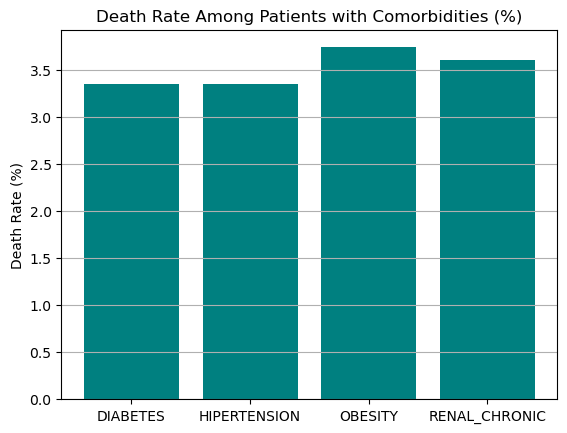

In [7]:
death_rates = {}

for comorbidity in comorbidities:
    rate = death_cases[comorbidity].sum() / df[comorbidity].sum() * 100
    death_rates[comorbidity] = round(rate, 2)

plt.bar(death_rates.keys(), death_rates.values(), color='teal')
plt.title('Death Rate Among Patients with Comorbidities (%)')
plt.ylabel('Death Rate (%)')
plt.grid(axis='y')
plt.show()
